In [77]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm
from torch.nn import Sequential, ReLU, Linear, Softmax, Module
import torch

## Approach 1: Q-learning with linear function approximation

In [78]:
STATE_MAX_VALUES = [2.4, 3.0, 0.21, 3.0]

In [ ]:
from numpy import float32

class QFA:
  def __init__(self, observation_space_size: int, action_space_size: int, alpha = 0.05, gamma = 0.95, epsilon = 1, epsilon_decay = 0.995, min_epsilon = 0.05) -> None:
    self.alpha = alpha # learning rate
    self.gamma = gamma # discount factor
    self.epsilon = epsilon # epsilon greedy start
    self.epsilon_decay = epsilon_decay # epsilon greedy decay
    self.min_epsion = min_epsilon # minimal epsilon value
    self.rng = np.random.default_rng()
    self.w = np.zeros((observation_space_size, action_space_size), dtype=np.float64)
    self.n_actions = action_space_size

  def train(self, env: gym.Env, n_episodes: int):
    rewards = np.zeros(n_episodes, dtype=float32)
    pbar = tqdm.trange(n_episodes, desc="Training", unit="episode")
    for ep in pbar:
      rewards[ep] = self._train_step(env)
      pbar.set_postfix({"reward": f"{rewards[ep]:.1f}", "epsilon": f"{self.epsilon:.3f}"})
    return rewards

  def choose_action(self, state):
    state = self._normalize_state(state)
    return self._best_q_action(state)

  def save_model(self, path):
    np.save(path, self.w)

  def load_model(self, path):
    self.w = np.load(path)

  def _train_step(self, env: gym.Env):
    episode_reward = 0.0
    state = self._normalize_state(env.reset()[0])
    while True:
      action = self._choose_action_train(env, state)
      new_state, reward, terminated, truncated, _info = env.step(action)
      episode_reward += float(reward)
      new_state = self._normalize_state(new_state)
      self.q_update(state, action, reward, new_state)
      if (terminated or truncated):
        break
      state = new_state
    self.epsilon = max(self.epsilon * self.epsilon_decay, self.min_epsion)
    return episode_reward

  def _q(self, state, action):
    state = np.array(state)
    return self.w[:, action] @ state

  def _best_q_action(self, state):
    return np.argmax(np.array([self._q(state, action) for action in range(self.n_actions)]))

  def _best_q_value(self, state):
    return np.max(np.array([self._q(state, action) for action in range(self.n_actions)]))

  def _normalize_state(self, state):
      state = np.array(state, dtype=np.float32)
      normed = state / STATE_MAX_VALUES
      return np.clip(normed, -1, 1)

  def q_update(self, state, action, reward, new_state):
    qsa = self._q(state, action)
    target = reward + self.gamma * self._best_q_value(new_state)
    error = target - qsa
    self.w[:, action] = self.w[:, action] + self.alpha * error * np.array(state)

  def _choose_action_train(self, env: gym.Env, state):
    if self.rng.random() < self.epsilon:
      return env.action_space.sample()
    else:
      return self._best_q_action(state)

In [80]:
N_EPISODES = 3500

env = gym.make("CartPole-v1", render_mode=None)
qfa = QFA(env.observation_space.shape[0], env.action_space.n)
rewards = qfa.train(env, N_EPISODES)

Training: 100%|██████████| 3500/3500 [00:17<00:00, 199.21episode/s, reward=500.0, epsilon=0.050] 


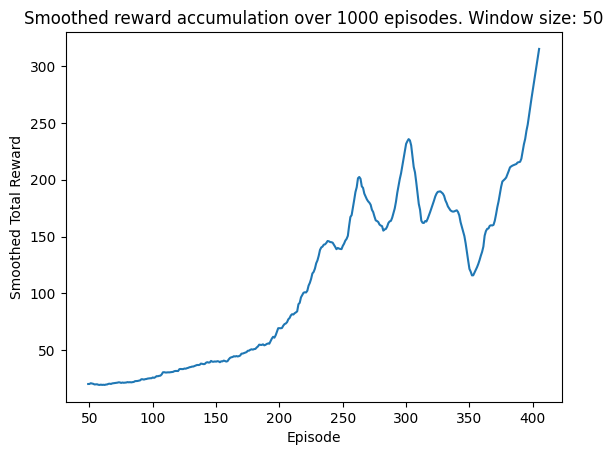

In [99]:
window_size = 50
rolling_rewards = pd.Series(rewards).rolling(window=window_size).mean()
plt.plot(rolling_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title(f"Smoothed reward accumulation over {N_EPISODES} episodes. Window size: {window_size}")
plt.show()

In [82]:
N_TEST_RUNS = 100
RENDER = None # set to "human" to enable game UI

env = gym.make("CartPole-v1", render_mode=RENDER)
test_reward = 0
for _ in range(N_TEST_RUNS):
  terminated = False
  truncated = False
  state = env.reset()[0]
  while not(terminated or truncated):
    state, r, terminated, truncated, _i = env.step(qfa.choose_action(state))
    test_reward += float(r)
print(f"{N_TEST_RUNS} games played")
print(f"Average reward per game: {test_reward/N_TEST_RUNS}")

100 games played
Average reward per game: 500.0


## Approach 2: Actor-Critic

In [91]:
class Actor(Module):
  def __init__(self, input_dim:int, output_dim:int, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.nn = Sequential(
      Linear(input_dim, 64),
      ReLU(),
      Linear(64, output_dim),
      Softmax(1)
    )
  def forward(self, x):
    return self.nn(x)

class Critic(Module):
  def __init__(self, input_dim:int, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.nn = Sequential(
      Linear(input_dim, 64),
      ReLU(),
      Linear(64, 1)
    )
  def forward(self, x):
    return self.nn(x)

In [92]:
class AC:
  def __init__(self, observation_space_size: int, action_space_size: int, actor_learning_rate = 5e-4, critic_learning_rate = 3e-3, gamma = 0.99, device: str = "mps"):
    self.device = device
    self.actor = Actor(observation_space_size, action_space_size).to(self.device)
    self.critic = Critic(observation_space_size).to(self.device)
    self.a_opt = torch.optim.Adam(self.actor.parameters(), lr=actor_learning_rate)
    self.c_opt = torch.optim.Adam(self.critic.parameters(), lr=critic_learning_rate)
    self.gamma = gamma
    self.n_perfect = 0

  def train(self, env: gym.Env, n_episodes: int):
    rewards = np.zeros(n_episodes, dtype=np.float32)
    pbar = tqdm.trange(n_episodes, desc="Training", unit="episode")
    ep = 0
    for ep in pbar:
      r = self._train_step(env)
      rewards[ep] = r
      self.n_perfect = self.n_perfect + 1 if r == 500.0 else 0
      if (self.n_perfect == 10):
        break
    return rewards[:ep]

  def _train_step(self, env: gym.Env):
    state = env.reset()[0]
    episode_reward = 0.0
    while True:
      state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
      action_probs = self.actor(state_tensor)
      action = np.random.choice(env.action_space.n, p=action_probs.cpu().detach().numpy()[0])
      next_state, reward, terminated, truncated, _ = env.step(action)
      episode_reward += float(reward)

      next_state_tensor = torch.tensor(next_state, dtype=torch.float32, device=self.device).unsqueeze(0)

      state_v = self.critic(state_tensor)
      if terminated or truncated:
          next_state_v = torch.tensor(0.0, dtype=torch.float32, device=self.device)
      else:
          next_state_tensor = torch.tensor(next_state, dtype=torch.float32, device=self.device).unsqueeze(0)
          with torch.no_grad():
              next_state_v = self.critic(next_state_tensor)

      advantage = reward + self.gamma * next_state_v - state_v

      actor_loss = -torch.log(action_probs[0, action] + 1e-8) * advantage
      critic_loss = advantage.pow(2)

      self.a_opt.zero_grad()
      self.c_opt.zero_grad()

      total_loss = (actor_loss + critic_loss)
      total_loss.backward()

      self.a_opt.step()
      self.c_opt.step()

      state = next_state
      if (terminated or truncated):
        break
    return episode_reward

  def choose_action(self, state):
    state_tensor = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
    with torch.no_grad():
      action_probs_tensor = self.actor(state_tensor)
      action_probs = action_probs_tensor.cpu().numpy()[0]
    return np.argmax(action_probs)

  def save_model(self, path="ac_path.pth"):
    torch.save(self.actor.state_dict(), path)

  def load_model(self, path="ac_path.pth"):
    self.actor.load_state_dict(torch.load(path))
    self.actor.eval()

In [93]:
N_EPISODES = 1000

env = gym.make("CartPole-v1", render_mode=None)
ac = AC(env.observation_space.shape[0], env.action_space.n)
rewards = ac.train(env, N_EPISODES)

Training:  41%|████      | 406/1000 [01:31<02:13,  4.44episode/s]


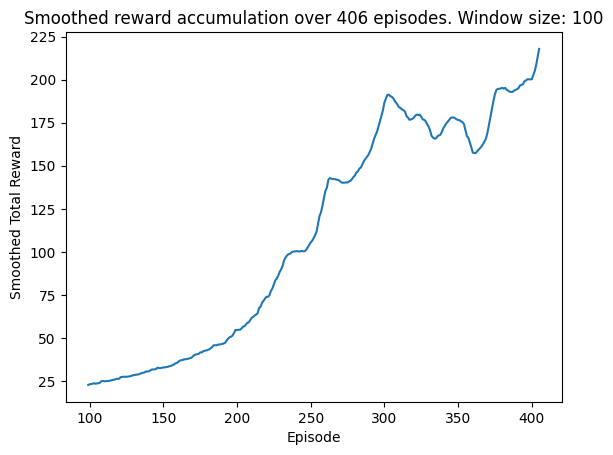

In [97]:
window_size = 100
rolling_rewards = pd.Series(rewards).rolling(window=window_size).mean()
rolling_rewards_no_zeros = rolling_rewards[rolling_rewards != 0]
plt.plot(rolling_rewards_no_zeros)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title(f"Smoothed reward accumulation over {len(rewards)} episodes. Window size: {window_size}")
plt.show()

In [95]:
N_TEST_RUNS = 100
RENDER = None # set to "human" to enable game UI

env = gym.make("CartPole-v1", render_mode=RENDER)
test_reward = 0
for _ in range(N_TEST_RUNS):
  terminated = False
  truncated = False
  state = env.reset()[0]
  while not(terminated or truncated):
    state, r, terminated, truncated, _i = env.step(ac.choose_action(state))
    test_reward += float(r)
print(f"{N_TEST_RUNS} games played")
print(f"Average reward per game: {test_reward/N_TEST_RUNS}")

100 games played
Average reward per game: 500.0
